In [1]:
print("hello")

hello


In [2]:
from modules.viz import MultiExperiment, metric_x_point, devplot
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
tcga = {
    'brca': MultiExperiment(
        experiment_dirs=[
            'output/2026-01-16_05h12m07s_benchmark_1_nbreconstr_tcga_BRCA',
            'output/2026-01-16_05h38m57s_benchmark_1_nbreconstr_tcga_BRCA',
            'output/2026-01-16_06h06m28s_benchmark_1_nbreconstr_tcga_BRCA',
            'output/2026-01-16_07h04m27s_benchmark_1_nbreconstr_tcga_BRCA',
            'output/2026-01-16_13h08m53s_benchmark_1_nbreconstr_tcga_BRCA',
        ],
        keys=[],
        out_dir='./experiments/benchmark_1_nbreconstr_tcga',
        overwrite=True
    ),

    'gbm': MultiExperiment(
        experiment_dirs=[
            'output/2026-01-16_05h27m35s_benchmark_1_nbreconstr_tcga_GBM',
            'output/2026-01-16_05h54m22s_benchmark_1_nbreconstr_tcga_GBM',
            'output/2026-01-16_06h40m35s_benchmark_1_nbreconstr_tcga_GBM',
            'output/2026-01-16_07h34m54s_benchmark_1_nbreconstr_tcga_GBM',
            'output/2026-01-16_14h14m47s_benchmark_1_nbreconstr_tcga_GBM',
        ],
        keys=[],
        out_dir='./experiments/benchmark_1_nbreconstr_tcga',
        overwrite=True
    ),

    'lgg': MultiExperiment(
        experiment_dirs=[
            'output/2026-01-16_05h32m39s_benchmark_1_nbreconstr_tcga_LGG',
            'output/2026-01-16_05h59m34s_benchmark_1_nbreconstr_tcga_LGG',
            'output/2026-01-16_06h51m37s_benchmark_1_nbreconstr_tcga_LGG',
            'output/2026-01-16_07h45m32s_benchmark_1_nbreconstr_tcga_LGG',
            'output/2026-01-16_14h36m10s_benchmark_1_nbreconstr_tcga_LGG',
            
        ],
        keys=[],
        out_dir='./experiments/benchmark_1_nbreconstr_tcga',
        overwrite=True
    ),

    'cortex': MultiExperiment(
        experiment_dirs=[
            'output/2026-01-20_12h25m52s_benchmark_1b_nbreconstr_scvi_cortex',
            
        ],
        keys=[],
        out_dir='./experiments/benchmark_1_nbreconstr_tcga',
        overwrite=True
    ),

    # 'pbmc': MultiExperiment(
    #     experiment_dirs=[
    #         'output/2026-01-20_12h50m05s_benchmark_1b_nbreconstr_scvi_pbmc_dataset',
    #     ],
    #     keys=[],
    #     out_dir='./experiments/benchmark_1_nbreconstr_tcga',
    #     overwrite=True
    # ),
}

for k,v in tcga.items():
    v.test['dataset'] = k

In [4]:
test = pd.concat([tcga[k].test for k in tcga.keys()], ignore_index=True)
test

,config,trial,metric,value,dataset
0,glm,0,loss,8.182627,brca
1,glm,0,mse,1.375683,brca
2,glm,0,rmse,1.172895,brca
3,glm,0,mae,0.767487,brca
4,glm,0,r2,0.640152,brca
...,...,...,...,...,...
4490,pathway-vae,4,kld,30.114031,cortex
4491,pathway-vae,4,nb,0.803257,cortex
4492,pathway-vae,4,time,216.210256,cortex
4493,pathway-vae,4,num_epochs,193.000000,cortex


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
test[test['metric']=='mae']

,config,trial,metric,value,dataset
3,glm,0,mae,0.767487,brca
12,glm,1,mae,0.745994,brca
21,glm,2,mae,0.744636,brca
30,glm,3,mae,0.728874,brca
39,glm,4,mae,0.716437,brca
...,...,...,...,...,...
4448,pathway-vae,0,mae,0.274774,cortex
4458,pathway-vae,1,mae,0.282046,cortex
4468,pathway-vae,2,mae,0.282266,cortex
4478,pathway-vae,3,mae,0.275033,cortex


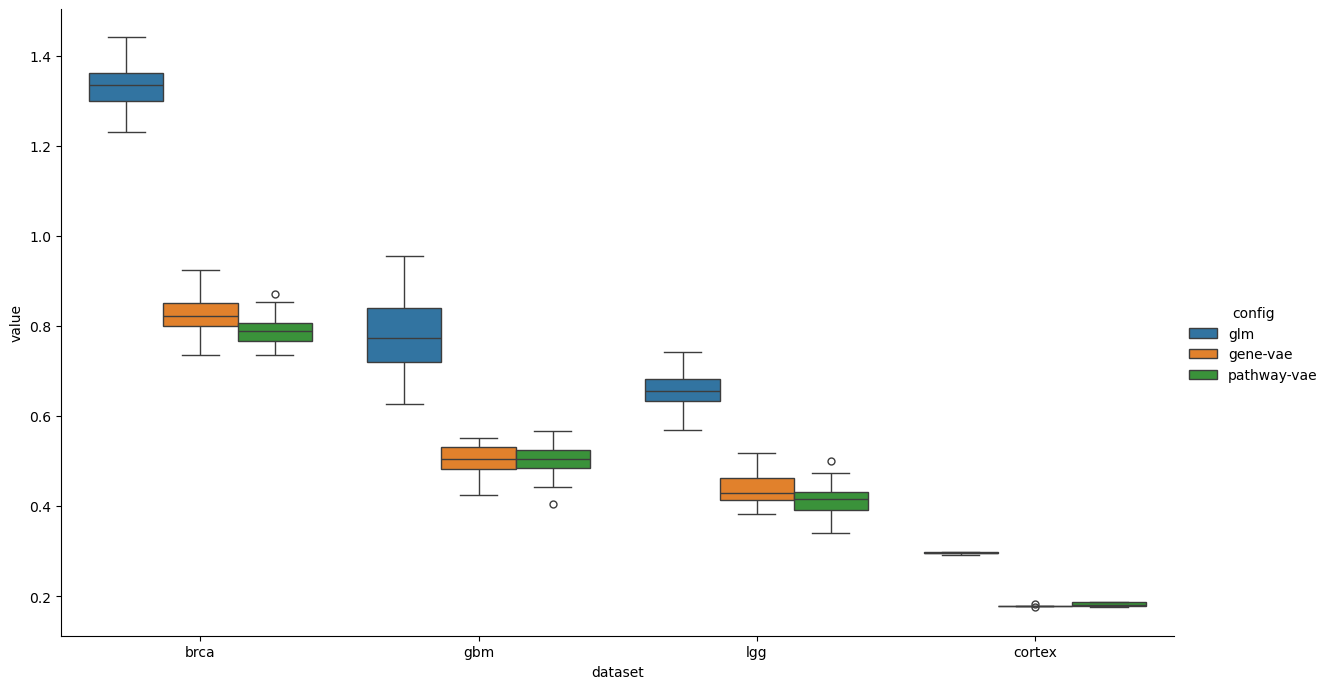

In [7]:
sns.catplot(
    data=test[test['metric']=='mse'],
    x='dataset',
    y='value',
    hue='config',
    kind='box',
    height=7,
    aspect=12/7,
)

---

In [9]:
# final thesis
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator
from itertools import combinations

In [12]:
df = test[test['metric']=='mse'].copy()
df = df.replace({
    'config': {'glm': 'GLM', 'gene-vae': 'Gene-only VAE', 'pathway-vae': 'Pathway VAE'},
    'dataset': {'brca': 'BRCA', 'gbm': 'GBM', 'lgg': 'LGG', 'cortex': 'CORTEX'},
    })
df

,config,trial,metric,value,dataset
1,GLM,0,mse,1.375683,BRCA
10,GLM,1,mse,1.321730,BRCA
19,GLM,2,mse,1.328996,BRCA
28,GLM,3,mse,1.241850,BRCA
37,GLM,4,mse,1.231324,BRCA
...,...,...,...,...,...
4446,Pathway VAE,0,mse,0.179768,CORTEX
4456,Pathway VAE,1,mse,0.186004,CORTEX
4466,Pathway VAE,2,mse,0.187529,CORTEX
4476,Pathway VAE,3,mse,0.178906,CORTEX


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

GBM_GLM vs. GBM_Gene-only VAE: t-test independent samples, P_val:1.202e-43 t=2.455e+01
LGG_GLM vs. LGG_Gene-only VAE: t-test independent samples, P_val:3.436e-50 t=2.923e+01
LGG_Gene-only VAE vs. LGG_Pathway VAE: t-test independent samples, P_val:7.108e-04 t=3.496e+00
CORTEX_GLM vs. CORTEX_Gene-only VAE: t-test independent samples, P_val:1.183e-12 t=7.443e+01
BRCA_GLM vs. BRCA_Gene-only VAE: t-test independent samples, P_val:2.404e-78 t=5.895e+01
BRCA_Gene-only VAE vs. BRCA_Pathway VAE: t-test independent samples, P_val:5.619e-06 t=4.803e+00
GBM_GLM vs. GBM_Pathway VAE: t-test independent samples, P_val:1.064e-43 t=2.458e+01
LGG_GLM vs. LGG_Pathway VAE: t-test independent samples, P_val:6.878e-57 t=3.473e+01
CORTEX_GLM vs. CORTEX_Pathway VAE: t-test independent samples, P_val:6.366e-11 t=4.518e+01

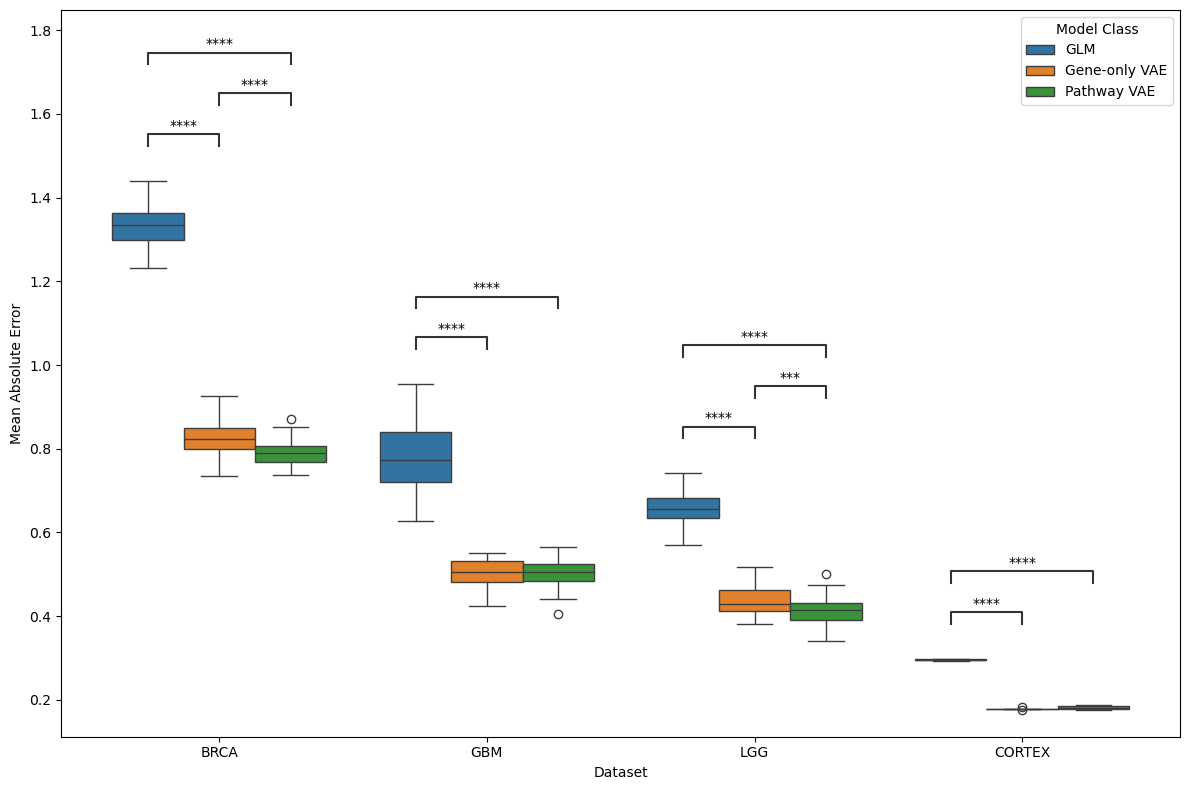

In [25]:
fig, ax = plt.subplots(figsize=(12, 8))
# sns.pointplot(data=df, x='config', y='value', hue='dataset', ax=ax)
sns.boxplot(data=df, x='dataset', y='value', hue='config', ax=ax)

pairs = []
for dataset in df['dataset'].unique():
    configs = df['config'].unique()
    for c1, c2 in combinations(configs, 2):
        pairs.append(
            ((dataset, c1), (dataset, c2))
        )

ann = Annotator(ax, pairs, data=df, x='dataset', y='value', hue='config')
ann.configure(test='t-test_ind', text_format='star', loc='inside', hide_non_significant=True)
ann.apply_and_annotate()

ax.set_xlabel("Dataset")
ax.set_ylabel("Mean Absolute Error")
ax.legend(title="Model Class")
plt.tight_layout()

---

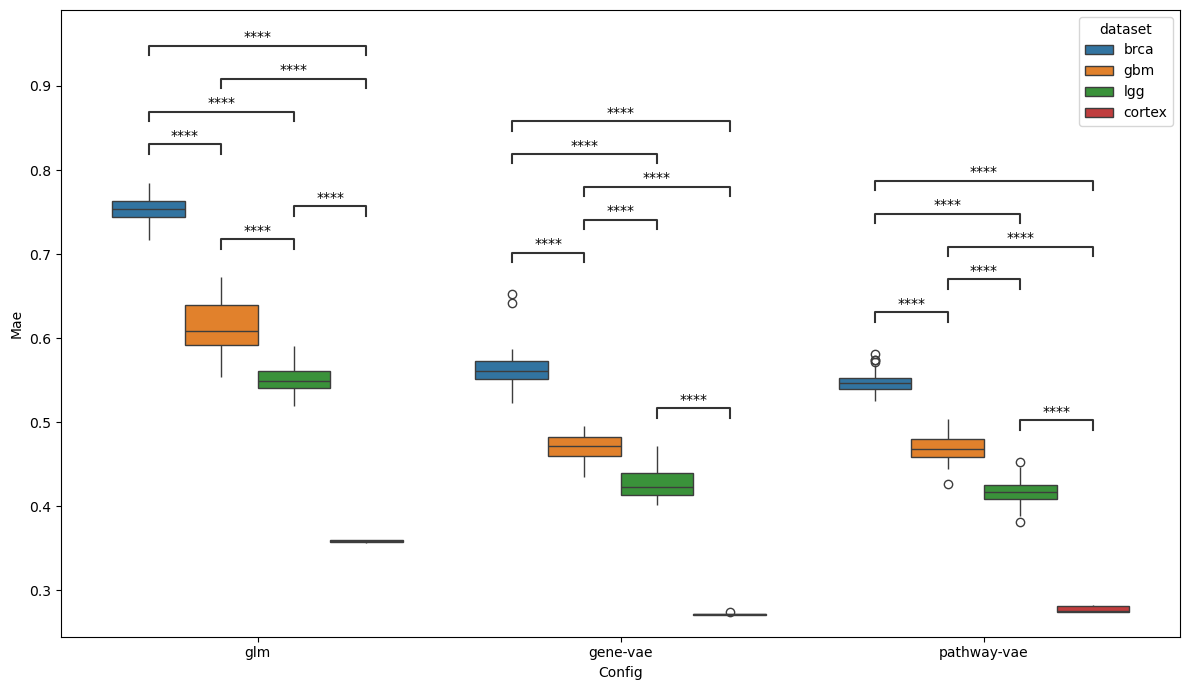

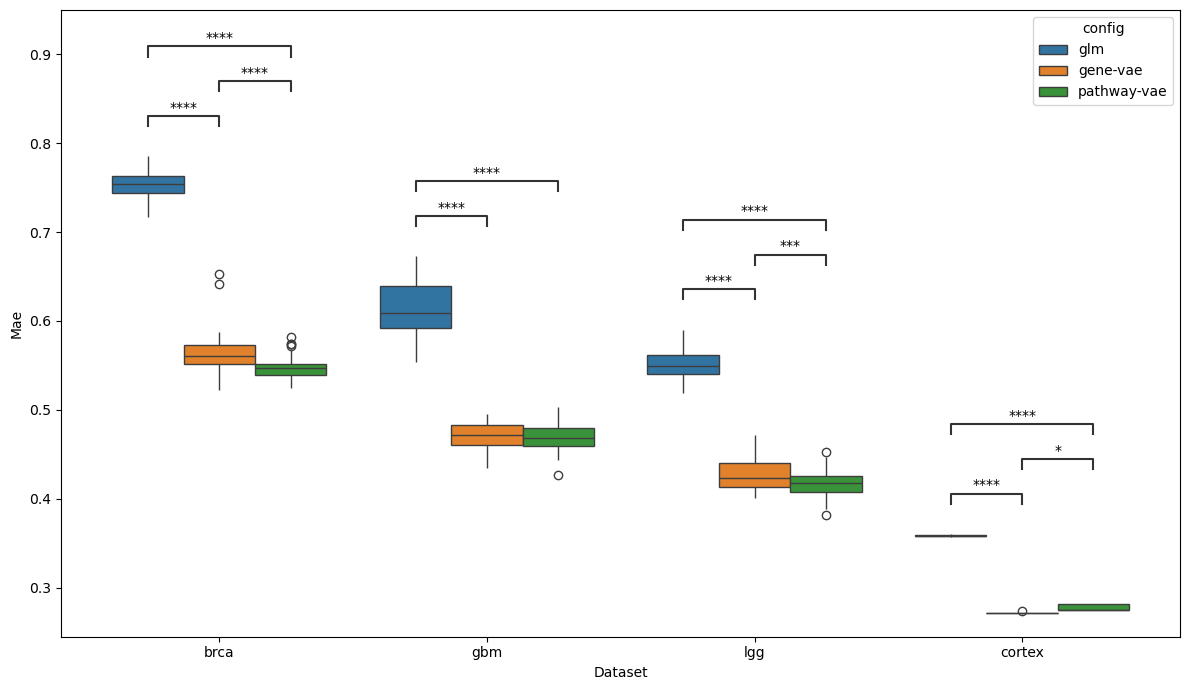

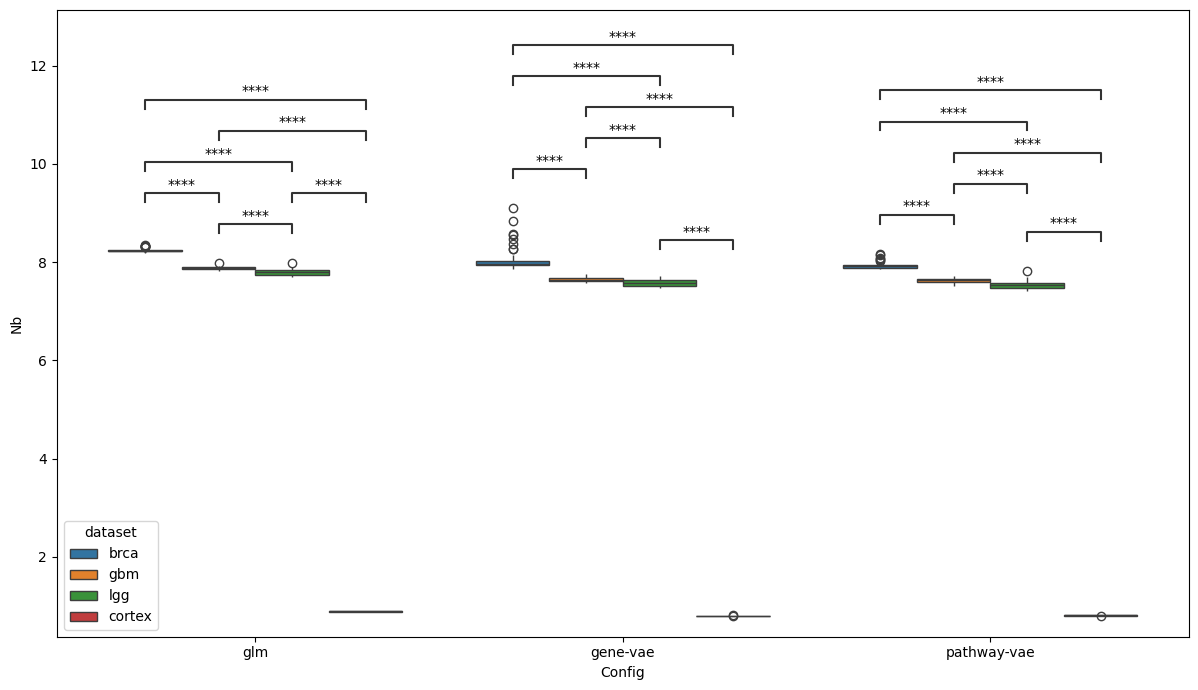

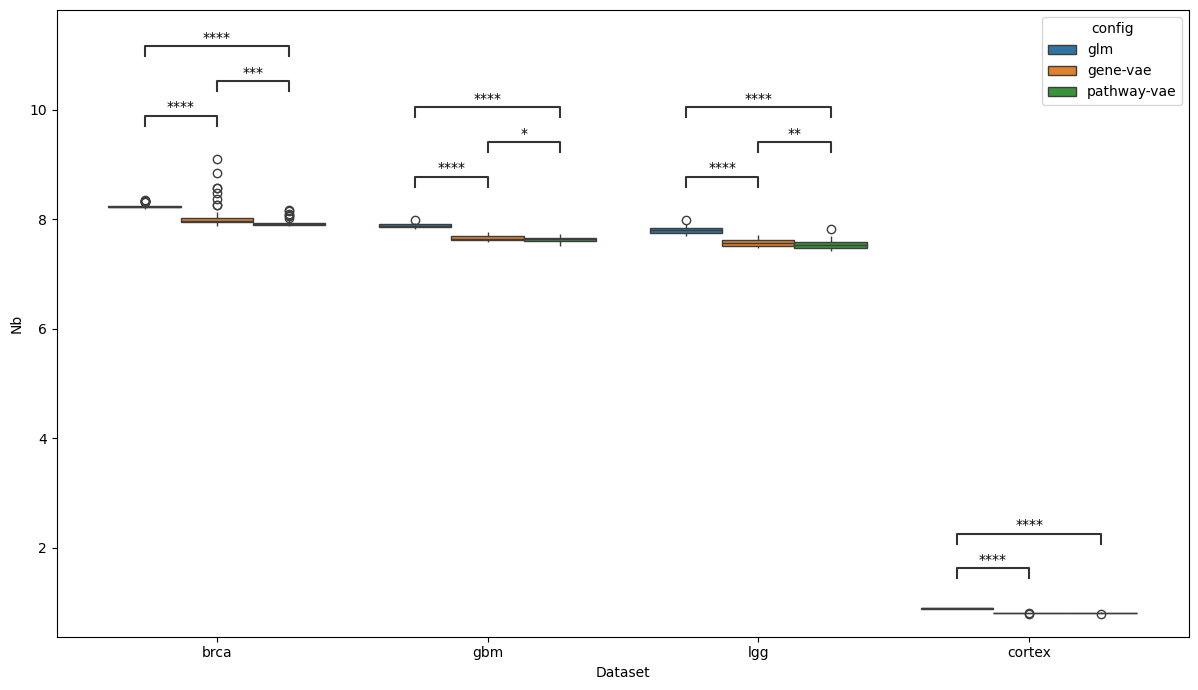

In [8]:
metric_x_point(
    df=test,
    cols=['config','dataset'],
    metrics=['mae', 'nb'],
    figsize=(12,7),
    # strip=True,
    sig='within',
    box=True,
    hue=True,
    dodge=True,
)